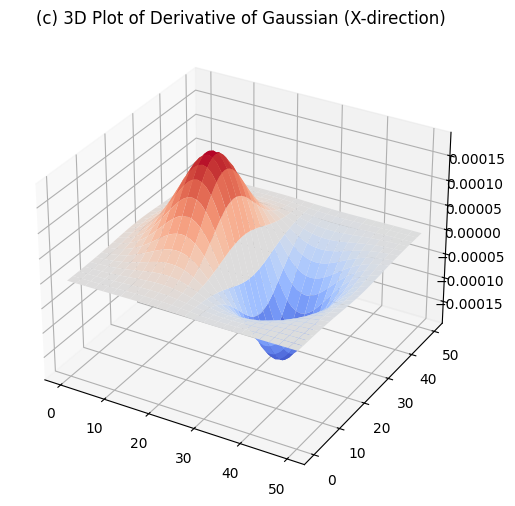

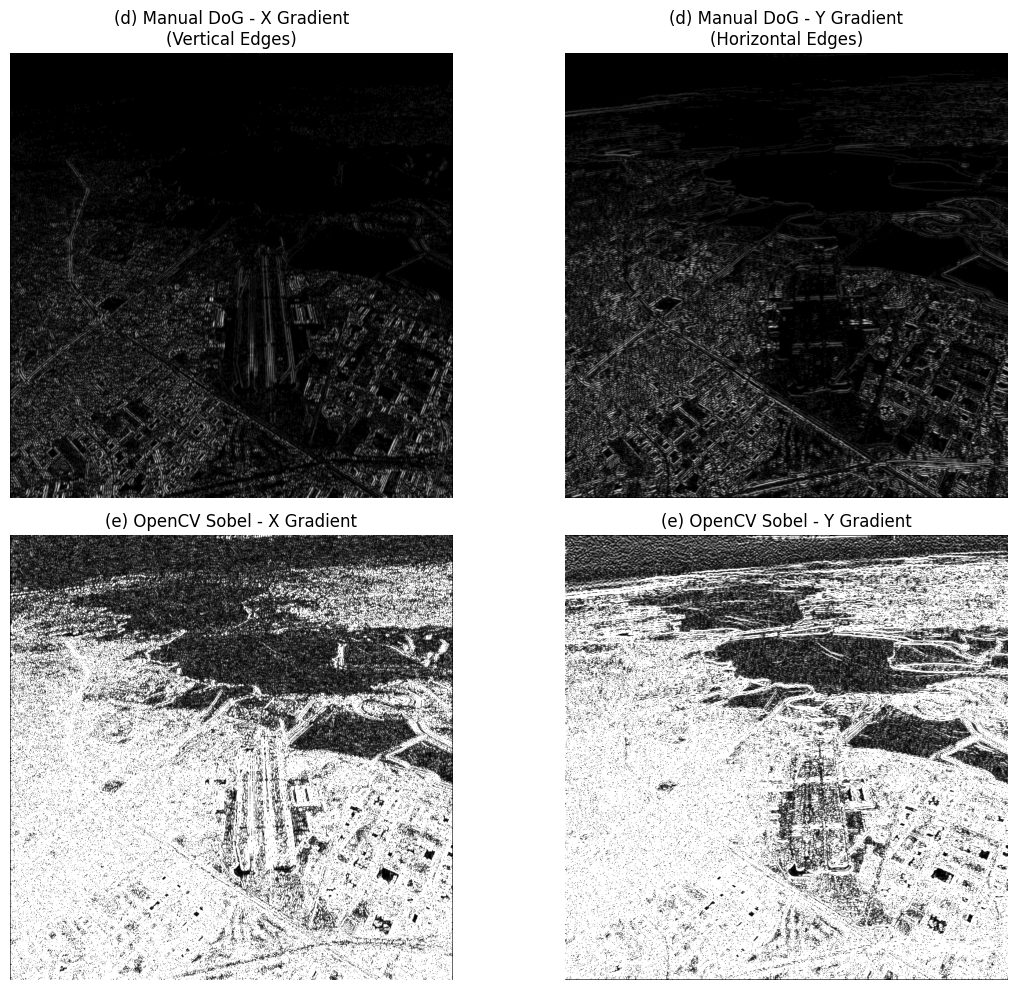

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#  Create Derivative of Gaussian  Kernels 
def get_dog_kernels(size, sigma):
    center = size // 2
    kernel_x = np.zeros((size, size))
    kernel_y = np.zeros((size, size))
    
    constant = 1 / (2 * np.pi * sigma**2)
    
    for x in range(size):
        for y in range(size):
            
            dx = x - center # Horizontal offset
            dy = y - center # Vertical offset
            
            # 1. Compute Base Gaussian value
            gauss_val = constant * np.exp(-(dx**2 + dy**2) / (2 * sigma**2))
            
            # 2. Compute Derivatives using Formula from 6(a)
            kernel_x[y, x] = -(dx / sigma**2) * gauss_val
            kernel_y[y, x] = -(dy / sigma**2) * gauss_val

    # Normalize kernels 
    return kernel_x, kernel_y


filename = 'runway.png'
file_path = fr"d:\computer_Vision_Inclass_11_26\{filename}"
img = cv.imread(file_path, cv.IMREAD_GRAYSCALE)

if img is None:
    print(" ERROR: Image not found.")
else:
    #  Compute 5x5 Kernels (sigma=2) 
    sigma = 2
    dog_x, dog_y = get_dog_kernels(5, sigma)

    #  Visualize 51x51 Kernel  as 3D Plot 
    size_viz = 51
    sigma_viz = 8 
    viz_dog_x, _ = get_dog_kernels(size_viz, sigma_viz)
    
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    X, Y = np.meshgrid(np.arange(size_viz), np.arange(size_viz))
    
    # Plotting the 'X-Derivative' Kernel
    ax.plot_surface(X, Y, viz_dog_x, cmap='coolwarm')
    ax.set_title('(c) 3D Plot of Derivative of Gaussian (X-direction)')
    plt.show()

    # Apply Manual DoG Filters 
    # Apply X-derivative kernel 
    grad_x_manual = cv.filter2D(img, cv.CV_64F, dog_x)
    # Apply Y-derivative kernel 
    grad_y_manual = cv.filter2D(img, cv.CV_64F, dog_y)
    
    abs_x_manual = cv.convertScaleAbs(grad_x_manual)
    abs_y_manual = cv.convertScaleAbs(grad_y_manual)

    # Compare with OpenCV Sobel 
    # Sobel X (Vertical Edges)
    sobel_x = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=5)
    # Sobel Y (Horizontal Edges)
    sobel_y = cv.Sobel(img, cv.CV_64F, 0, 1, ksize=5)
    
    abs_sobel_x = cv.convertScaleAbs(sobel_x)
    abs_sobel_y = cv.convertScaleAbs(sobel_y)

    # Display Results
    plt.figure(figsize=(12, 10))

    # Manual DoG
    plt.subplot(2, 2, 1)
    plt.imshow(abs_x_manual, cmap='gray')
    plt.title('(d) Manual DoG - X Gradient\n(Vertical Edges)')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(abs_y_manual, cmap='gray')
    plt.title('(d) Manual DoG - Y Gradient\n(Horizontal Edges)')
    plt.axis('off')

    # OpenCV Sobel
    plt.subplot(2, 2, 3)
    plt.imshow(abs_sobel_x, cmap='gray')
    plt.title('(e) OpenCV Sobel - X Gradient')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(abs_sobel_y, cmap='gray')
    plt.title('(e) OpenCV Sobel - Y Gradient')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    
    